# **MLP predictor for ECH index**

Here's an outline of what I want to do:
 - Download the data for ECH from Yahoo Finance, just as they do in the paper, for the same time span and 6 fundamental indicators.
 - Preprocess the data like the paper does
 - Assign a class like they do in the paper with the Gamma function:
+1 if the open price increased, -1 if it decreased.
 - Compute the extra technical indicators using Pandas TA
 - Clean and normalise the dataset. Careful not to normalise the class of course.
 - Calculate the Pearson correlation between each technical indicator and the class.
 - Select the top 10 indicators according to the highest correlation scores. This set will be called "top_10". Make a list of them and print it.
 - Use the top_10 set to train an MLP neural network in a 10-fold cross-validation setup.
 - Assess the accruacy of the MLP model with every partition and find the average accurace across all 10 folds. Report this as the average accuracy of the MLP model.
 - Produce graphs and tables that visualise our resutls and the information we have used and obtained.

### ---- Initialisation ----

In [5]:
# ======================================
# Initialisation -- import libraries
# ======================================

# Core
import numpy as np
import pandas as pd
import time

# Data download
import yfinance as yf

# Technical indicators
# !pip install pandas-ta   # May need to install it first   ------ IGNORE FOR PYTHON 3.11 ------
# !pip install pandas-ta-classic --quiet   # May need to install this too
# !pip install TA-Lib --quiet     # May need to install this too
# import pandas_ta as ta                                  # ------ IGNORE FOR PYTHON 3.11 ------
import pandas_ta_classic as ta

# Machine learning
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

# Feature analysis
from scipy.stats import pearsonr

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Plot style (publication-like, clean)
sns.set_theme(style="darkgrid", context="talk")

### ---- Download data ----

In [2]:
# =========================
# Download ECH data
# =========================

# Specify ticker and time frame
ticker = "ECH"
start_date = "2009-01-01"
end_date = "2020-01-01"

# Download data from Yahoo Finance
df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False
)

# Since we only download one ETF, remove unnecessary Ticker MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].copy()

# Visualize the data
print("\n")
print("Data shape:", df.shape)
display(df)

[*********************100%***********************]  1 of 1 completed



Data shape: (2768, 6)


Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-01-02,29.500000,30.350000,29.500000,30.350000,20.116993,45600
2009-01-05,30.620001,30.620001,30.150000,30.299999,20.083851,56600
2009-01-06,31.580000,31.620001,31.000000,31.350000,20.779829,113900
2009-01-07,31.860001,31.860001,30.860001,30.990000,20.541208,9400
2009-01-08,30.910000,31.270000,30.900000,31.270000,20.726801,14600
...,...,...,...,...,...,...
2019-12-24,33.549999,33.709999,33.320000,33.490002,26.451025,134300
2019-12-26,33.490002,33.639999,33.369999,33.570000,26.514208,295400
2019-12-27,33.529999,33.650002,33.139999,33.459999,26.427326,209700


### ---- Price history plot ----

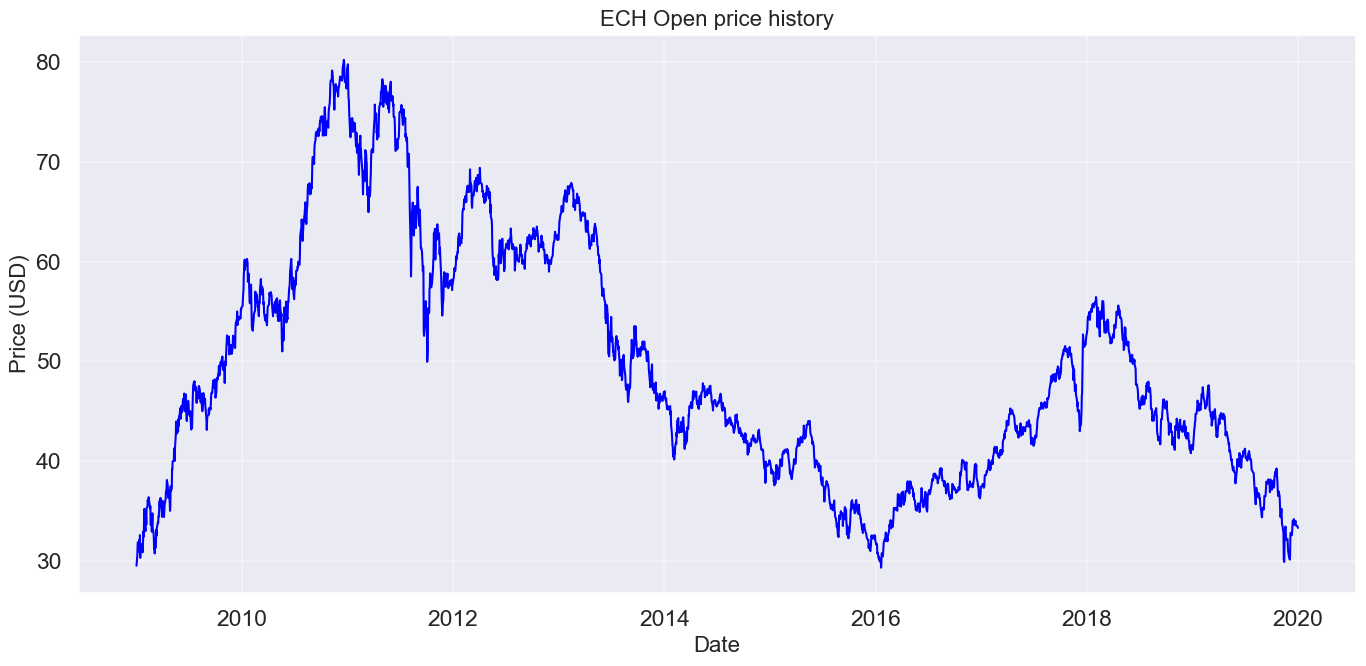

In [6]:
# ==============================================
# Plot ECH price history
# ==============================================

# Plot the Adjusted prices
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Open'], color='blue', linewidth=1.5)
plt.title(f'{ticker} Open price history', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Price (USD)', fontsize=16)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

### ---- Assign class – Gamma function ----

In [7]:
# =========================
# Assign class (Gamma)
# =========================

# Compute previous day's Open
df["Open_prev"] = df["Open"].shift(1)

# Assign class: +1 if Open_t > Open_{t-1}, else -1
df["Class"] = np.where(df["Open"] > df["Open_prev"], 1, -1)

# Cumulative Gamma
df["Gamma_cum"] = df["Class"].cumsum() + 1  # +1 to counter the initial row being -1

# Visualize
print("\n", "Data shape after class assignment:", df.shape, "\n")

display(df)


 Data shape after class assignment: (2768, 9) 



Price,Open,High,Low,Close,Adj Close,Volume,Open_prev,Class,Gamma_cum
Date,,,,,,,,,
2009-01-02,29.500000,30.350000,29.500000,30.350000,20.116993,45600,NaN,-1,0
2009-01-05,30.620001,30.620001,30.150000,30.299999,20.083851,56600,29.500000,1,1
2009-01-06,31.580000,31.620001,31.000000,31.350000,20.779829,113900,30.620001,1,2
2009-01-07,31.860001,31.860001,30.860001,30.990000,20.541208,9400,31.580000,1,3
2009-01-08,30.910000,31.270000,30.900000,31.270000,20.726801,14600,31.860001,-1,2
...,...,...,...,...,...,...,...,...,...
2019-12-24,33.549999,33.709999,33.320000,33.490002,26.451025,134300,33.980000,-1,-5
2019-12-26,33.490002,33.639999,33.369999,33.570000,26.514208,295400,33.549999,-1,-6
2019-12-27,33.529999,33.650002,33.139999,33.459999,26.427326,209700,33.490002,1,-5


#### Display adjacent pairs of equal Open prices

In [8]:
# =========================
# Display equal Open pairs
# =========================

# Find rows where Open(t) == Open(t-1)
mask = df["Open"] == df["Open_prev"]

# Display pairs (previous day + current day)
pairs = df.loc[mask | mask.shift(-1)].copy()

print("\n", "Pairs of consecutive days with equal Open prices:", "\n")
# display(pairs[["Open", "Open_prev", "Class"]])
display(pairs[["Open", "Open_prev", "Class"]].head(10))


# Count equal cases
equal_count = mask.sum()
total_count = len(df)

print("\n", "Number of days with Open(t) == Open(t-1):", equal_count)
print("Percentage of dataset: {:.6f}%".format(100 * equal_count / total_count))


 Pairs of consecutive days with equal Open prices: 



Price,Open,Open_prev,Class
Date,,,
2010-07-08,59.099998,57.689999,1
2010-07-09,59.099998,59.099998,-1
2011-02-28,69.120003,68.010002,1
2011-03-01,69.120003,69.120003,-1
2011-03-30,70.970001,71.260002,-1
2011-03-31,70.970001,70.970001,-1
2011-06-30,74.980003,73.540001,1
2011-07-01,74.980003,74.980003,-1
2013-09-30,50.470001,51.430000,-1



 Number of days with Open(t) == Open(t-1): 19
Percentage of dataset: 0.686416%


#### Cumulative Gamma plot

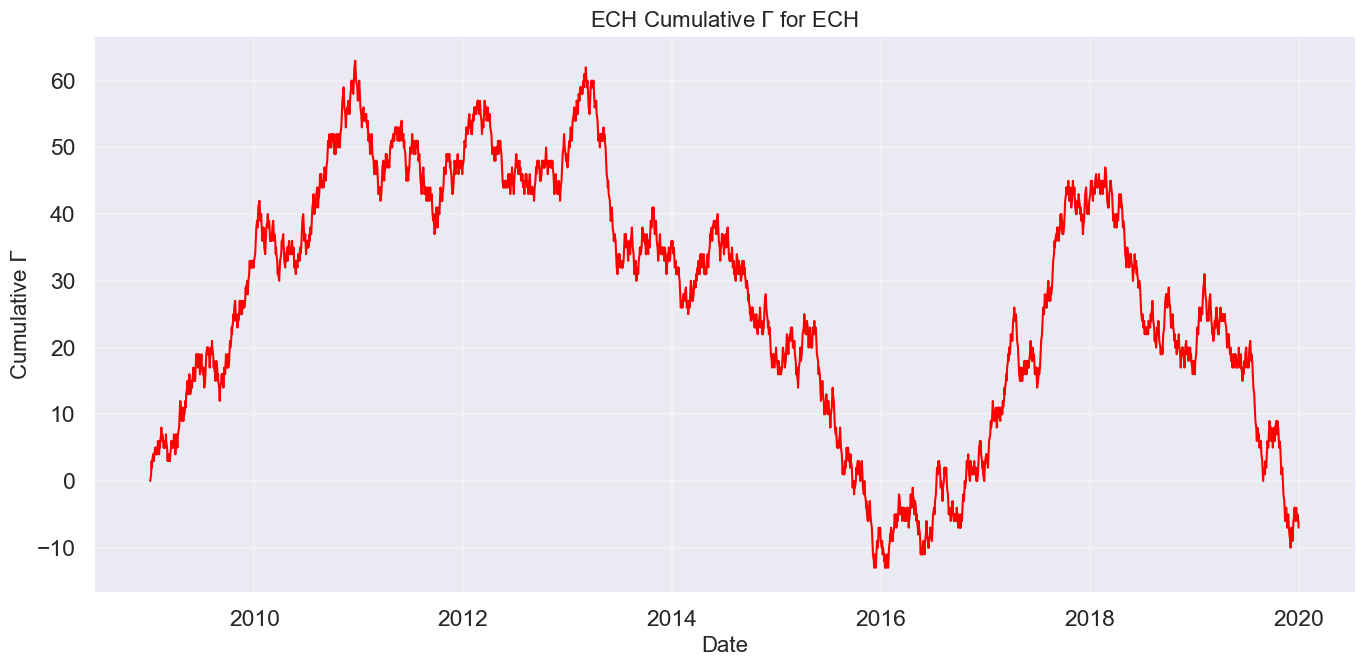

In [9]:
# ==============================================
# Plot Cumultaive Gamma
# ==============================================

# Plot the Adjusted prices
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["Gamma_cum"], color='red', linewidth=1.5)
plt.title(rf'{ticker} Cumulative $\Gamma$ for {ticker}', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel(r'Cumulative $\Gamma$', fontsize=16)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

### ---- Compute technical indicators with Pandas-TA ----

In [10]:
# ==================================================================
# Compute all technical indicators with Pandas-TA and TA-Lib
# ==================================================================

# Run "study" to compute and append all available technical indicators.
df.ta.strategy()

# Visualise all technical indicators calculated
display(df)


Price,Open,High,Low,Close,Adj Close,Volume,Open_prev,Class,Gamma_cum,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,ACOS,AD,ADD,ADOSC_3_10,ADX_14,DMP_14,DMN_14,ADXR_14,ALMA_10_6.0_0.85,AMATe_LR_8_21_2,AMATe_SR_8_21_2,AO_5_34,OBV,OBV_min_2,OBV_max_2,OBVe_4,OBVe_12,AOBV_LR_2,AOBV_SR_2,APO_12_26,AROOND_14,AROONU_14,AROONOSC_14,ASIN,ATAN,ATRr_14,AVGPRICE,AVOLUME_20,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0,BIAS_SMA_26,BOP,AR_26,BR_26,CCI_14_0.015,CDL_DOJI_10_0.1,CDL_INSIDE,CDL_2CROWS,CDL_3BLACKCROWS,CDL_3INSIDE,CDL_3LINESTRIKE,CDL_3OUTSIDE,CDL_3STARSINSOUTH,CDL_3WHITESOLDIERS,CDL_ABANDONEDBABY,CDL_ADVANCEBLOCK,CDL_BELTHOLD,CDL_BREAKAWAY,CDL_CLOSINGMARUBOZU,CDL_CONCEALBABYSWALL,CDL_COUNTERATTACK,CDL_DARKCLOUDCOVER,CDL_DOJISTAR,CDL_DRAGONFLYDOJI,CDL_ENGULFING,CDL_EVENINGDOJISTAR,CDL_EVENINGSTAR,CDL_GAPSIDESIDEWHITE,CDL_GRAVESTONEDOJI,CDL_HAMMER,CDL_HANGINGMAN,CDL_HARAMI,CDL_HARAMICROSS,CDL_HIGHWAVE,CDL_HIKKAKE,CDL_HIKKAKEMOD,CDL_HOMINGPIGEON,CDL_IDENTICAL3CROWS,CDL_INNECK,CDL_INVERTEDHAMMER,CDL_KICKING,CDL_KICKINGBYLENGTH,CDL_LADDERBOTTOM,CDL_LONGLEGGEDDOJI,CDL_LONGLINE,CDL_MARUBOZU,CDL_MATCHINGLOW,CDL_MATHOLD,CDL_MORNINGDOJISTAR,CDL_MORNINGSTAR,CDL_ONNECK,CDL_PIERCING,CDL_RICKSHAWMAN,CDL_RISEFALL3METHODS,CDL_SEPARATINGLINES,CDL_SHOOTINGSTAR,CDL_SHORTLINE,CDL_SPINNINGTOP,CDL_STALLEDPATTERN,CDL_STICKSANDWICH,CDL_TAKURI,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,open_Z_30_1,high_Z_30_1,low_Z_30_1,close_Z_30_1,CE_L_22_3.0,CE_S_22_3.0,CEIL,CFO_9,CG_10,CHOP_14_1_100,CKSPl_10_3_20,CKSPs_10_3_20,CMF_20,CMO_14,COPC_11_14_10,COS,COSH,CPR_TC,CPR_PIVOT,CPR_BC,CPR_R1,CPR_R2,CPR_S1,CPR_S2,CPR_WIDTH,CPR_WIDTH_PCT,CPR_WIDTH_CLASS,CPR_POSITION,Close_X_Close,Close_XA_Close,CTI_12,CVI_10,LDECAY_5,DEC_1,DEMA_10,DIV,DCL_20_20,DCM_20_20,DCU_20_20,DPO_20,DD,DD_PCT,DD_LOG,DSP_14,DX_14,EBSW_40_10,EDECAY_5,EFI_13,EMA_10,EMV,ENTP_10,EOM_14_100000000,ER_10,BULLP_13,BEARP_13,EXP,FISHERT_9_1,FISHERTs_9_1,FLOOR,FOSC_14,FWMA_10,HA_open,HA_high,HA_low,HA_close,HILO_13_21,HILOl_13_21,HILOs_13_21,HL2,HLC3,HMA_10,HT_DCPERIOD,HT_DCPHASE,HT_PHASOR_INPHASE,HT_PHASOR_QUAD,HT_SINE,HT_LEADSINE,HT_TRENDLINE,HT_TRENDMODE,HVOL_20,HWM,HWU,HWL,HWMA_0.2_0.1_0.1,ISA_9,ISB_26,ITS_9,IKS_26,ICS_26,INC_1,INERTIA_20_14,JMA_7_0,KAMA_10_2_30,KCLe_20_2,KCBe_20_2,KCUe_20_2,K_9_3,D_9_3,J_9_3,KST_10_15_20_30_10_10_10_15,KSTs_9,KURT_30,KVO_34_55_13,KVOs_34_55_13,LAG_1,LR_14,LRa_14,LRb_14,LRm_14,LN,LOG10,LOGRET_1,LRSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,MACDEXT_12_26_9,MACDEXTs_12_26_9,MACDEXTh_12_26_9,MACDFIX_9_9,MACDFIXh_9_9,MACDFIXs_9_9,MAD_30,MAMA_0.5_0.05,FAMA_0.5_0.05,MARKETFI,MASSI_9_25,MAVP_2_30,MAXINDEX_30,MCGD_10,MD_30,MEDIAN_30,MEDPRICE,MFI_14,MIDPOINT_2,MIDPRICE_2,MININDEX_30,MIN_30,MAX_30,MINIDX_30,MAXIDX_30,MINUS_DM_14,MMAR_10,MMAR_15,MMAR_20,MMAR_25,MMAR_30,MMAR_35,MOM_10,MSW_SINE_5,MSW_LEAD_5,MULT,NATR_14,ABS,ROUND,NVI_1,OHLC4,PDIST,PCTRET_1,PGO_14,PLUS_DM_14,PMAX_E_10_3.0,PO_14,PPO_12_26_9,PPOh_12_26_9,PPOs_12_26_9,PSARl_0.02_0.2,PSARs_0.02_0.2,PSARaf_0.02_0.2,PSARr_0.02_0.2,PSL_12,PVI_1,PVO_12_26_9,PVOh_12_26_9,PVOs_12_26_9,PVOL,PVR,PVT,PWMA_10,QQE_14_5_4.236,QQE_14_5_4.236_RSIMA,QQEl_14_5_4.236,QQEs_14_5_4.236,QQEb_l_14_5_4.236,QQEb_s_14_5_4.236,QQEd_14_5_4.236,QS_10,QTL_30_0.5,RAINBOW_1,RAINBOW_2,RAINBOW_3,RAINBOW_4,RAINBOW_5,RAINBOW_6,RAINBOW_7,RAINBOW_8,RAINBOW_9,RAINBOW_10,RMA_10,ROC_10,ROCP_10,ROCR_10,ROCR100_10,SUM_30,RSI_14,RSX_14,RVGIh_14_4,RVGI_14_4,RVGIs_14_4,RVI_14,SAREXT,SIN,SINH,SINWMA_14,SKEW_30,SLOPE_1,SMA_10,SMI_5_20_5,SMIs_5_20_5,SMIo_5_20_5,SQRT,SQZ_20_2.0_20_1.5,SQZ_ON,SQZ_OFF,SQZ_NO,SQZPRO_20_2.0_20_2_1.5_1,SQZPRO_ON_WIDE,SQZPRO_ON_NORMAL,SQZPRO_ON_NARROW,SQZPRO_OFF,SQZPRO_NO,SSF_10_2,STC_10_12_26_0.5,STCmacd_10_12_26_0.5,STCstoch_10_12_26_0.5,STDERR_14,STDEV_30,STOCHk_14_3_3,STOCHd_14_3_3,STOCHFk_5_3,STOCHFd_5_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,SUB,SUPERT_7_3.0,SUPERTd_7_3.0,SUPERTl_7_3.0,SUPERTs_7_3.0,SWMA_10,T3_10_0.7,TAN,TANH,TEMA_10,THERMO_

In [12]:
# ================================================
# List all column names (technical indicators)
# ================================================

cols = df.columns.tolist()
# print(cols)

# Find total number of columns (technical indicators) and how many were added by Pandas-TA
n_total = len(cols)
n_added = n_total - 9  # there were already 9 to start with

# Display all column names
display(pd.DataFrame({"Column": cols}))

print("\n", f"Total number of technical indicators: {n_total}")
print("\n", f"Added TA columns: {n_added}", "\n")


,Column
0,Open
1,High
2,Low
3,Close
4,Adj Close
...,...
410,WCP
411,WILLR_14
412,WMA_10
413,ZL_EMA_10



 Total number of technical indicators: 415

 Added TA columns: 406 



### ---- Clean data ----

In [13]:
# ===============================================================
# Find what columns have way too many NaNs to remove them
# ===============================================================

# Percentage of NaNs per column
nan_pct = df.isna().mean().copy() * 100

nan_pct.index.name = 'Tech Indicators NaN % (sorted)'
display(nan_pct.sort_values(ascending=False).head(20))

# Scan thresholds from 0% to 60%
for x in [0, 5, 10, 20, 30, 40, 50]:
    cols = nan_pct[nan_pct > x].index.tolist()

    print(f"\n Number of columns with > {x}% NaNs: {len(cols)}")
    # Uncomment if you want to see names
    print(cols)

Tech Indicators NaN % (sorted)
ASIN                 100.000000
ACOS                 100.000000
SUPERTs_7_3.0         53.865607
PSARs_0.02_0.2        53.323699
QQEs_14_5_4.236       52.745665
QQEl_14_5_4.236       49.819364
PSARl_0.02_0.2        46.712428
SUPERTl_7_3.0         46.387283
HILOs_13_21           42.341040
HILOl_13_21           40.823699
VFI_130                9.429191
TRIXs_30_9             3.468208
TRIX_30_9              3.179191
ISB_26                 2.781792
QQE_14_5_4.236         2.565029
QQEb_s_14_5_4.236      2.528902
QQEb_l_14_5_4.236      2.528902
KVOs_34_55_13          2.384393
TRIXs_18_9             2.167630
TRIXh_18_9             2.167630
dtype: float64


 Number of columns with > 0% NaNs: 254
['Open_prev', 'ABER_ZG_5_15', 'ABER_SG_5_15', 'ABER_XG_5_15', 'ABER_ATR_5_15', 'ACCBL_20', 'ACCBM_20', 'ACCBU_20', 'ACOS', 'ADOSC_3_10', 'ADX_14', 'DMP_14', 'DMN_14', 'ADXR_14', 'ALMA_10_6.0_0.85', 'AO_5_34', 'OBV_min_2', 'OBV_max_2', 'OBVe_4', 'OBVe_12', 'APO_12_26', 'AROOND_14', 'AROONU_14', 'AROONOSC_14', 'ASIN', 'ATRr_14', 'AVOLUME_20', 'BBL_5_2.0', 'BBM_5_2.0', 'BBU_5_2.0', 'BBB_5_2.0', 'BBP_5_2.0', 'BIAS_SMA_26', 'AR_26', 'BR_26', 'CCI_14_0.015', 'open_Z_30_1', 'high_Z_30_1', 'low_Z_30_1', 'close_Z_30_1', 'CE_L_22_3.0', 'CE_S_22_3.0', 'CFO_9', 'CG_10', 'CHOP_14_1_100', 'CKSPl_10_3_20', 'CKSPs_10_3_20', 'CMF_20', 'CMO_14', 'COPC_11_14_10', 'CPR_TC', 'CPR_PIVOT', 'CPR_BC', 'CPR_R1', 'CPR_R2', 'CPR_S1', 'CPR_S2', 'CPR_WIDTH', 'CPR_WIDTH_PCT', 'CTI_12', 'CVI_10', 'DEMA_10', 'DCL_20_20', 'DCM_20_20', 'DCU_20_20', 'DPO_20', 'DSP_14', 'DX_14', 'EBSW_40_10', 'EFI_13', 'EMA_10', 'EMV', 'ENTP_10', 'EOM_14_100000000', 'ER_10', 'BULLP_13', 'BEARP_13', 

In [14]:
# ==================================================
# NaN percentage scan (columns)
# ==================================================

# Percentage of NaNs per column
nan_pct = df.isna().mean().copy() * 100

# Scan thresholds from 0% to 60% in steps of 5%
for x in range(0, 60, 5):
    cols = nan_pct[nan_pct < x].index.tolist()

    print(f"\n Number of columns with < {x}% NaNs: {len(cols)}")
    # Uncomment if you want to see names
    # print(cols)


 Number of columns with < 0% NaNs: 0

 Number of columns with < 5% NaNs: 404

 Number of columns with < 10% NaNs: 405

 Number of columns with < 15% NaNs: 405

 Number of columns with < 20% NaNs: 405

 Number of columns with < 25% NaNs: 405

 Number of columns with < 30% NaNs: 405

 Number of columns with < 35% NaNs: 405

 Number of columns with < 40% NaNs: 405

 Number of columns with < 45% NaNs: 407

 Number of columns with < 50% NaNs: 410

 Number of columns with < 55% NaNs: 413


After inspecting the columns, we decide to remove all columns with more than 5% NaNs. This way we will drop less rows due to NaNs too.

In [15]:
# Max percentage of NaNs allowed in columns
nan_thresh = 0.05

# Calculate threshold - i.e. minimum number of non-NaNs to keep the column
threshold = int((1 - nan_thresh) * df.shape[0])
print(threshold)

2629


In [16]:
# =========================
# Data cleaning
# =========================

rows_before_cleaning = df.shape[0]
cols_before_cleaning = df.shape[1]

# Drop columns with too many NaNs (e.g. >5%)
df = df.dropna(thresh=threshold, axis=1).copy()

# Drop auxiliary "Open_prev" column
df = df.drop(columns=['Open_prev'], errors='ignore').copy()

# Drop non-numeric columns (if any)
df = df.select_dtypes(include=['number']).copy()

cols_after_cleaning = df.shape[1]
cols_removed = cols_before_cleaning - cols_after_cleaning

# Drop rows with any remaining NaNs
df = df.dropna().copy()

rows_after_cleaning = df.shape[0]
rows_cleaned = rows_before_cleaning - rows_after_cleaning

# Visualize
print("\n", cols_removed, "NaN, non-numeric and auxiliary columns have been removed.")
print(rows_cleaned, "rows with NaN have been cleaned.")
print("\n", "We now have", rows_after_cleaning, "rows and", df.shape[1], "columns (indicators) in the dataset.", "\n")

display(df)


 14 NaN, non-numeric and auxiliary columns have been removed.
122 rows with NaN have been cleaned.

 We now have 2646 rows and 401 columns (indicators) in the dataset. 



Price,Open,High,Low,Close,Adj Close,Volume,Class,Gamma_cum,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,AD,ADD,ADOSC_3_10,ADX_14,DMP_14,DMN_14,ADXR_14,ALMA_10_6.0_0.85,AMATe_LR_8_21_2,AMATe_SR_8_21_2,AO_5_34,OBV,OBV_min_2,OBV_max_2,OBVe_4,OBVe_12,AOBV_LR_2,AOBV_SR_2,APO_12_26,AROOND_14,AROONU_14,AROONOSC_14,ATAN,ATRr_14,AVGPRICE,AVOLUME_20,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0,BIAS_SMA_26,BOP,AR_26,BR_26,CCI_14_0.015,CDL_DOJI_10_0.1,CDL_INSIDE,CDL_2CROWS,CDL_3BLACKCROWS,CDL_3INSIDE,CDL_3LINESTRIKE,CDL_3OUTSIDE,CDL_3STARSINSOUTH,CDL_3WHITESOLDIERS,CDL_ABANDONEDBABY,CDL_ADVANCEBLOCK,CDL_BELTHOLD,CDL_BREAKAWAY,CDL_CLOSINGMARUBOZU,CDL_CONCEALBABYSWALL,CDL_COUNTERATTACK,CDL_DARKCLOUDCOVER,CDL_DOJISTAR,CDL_DRAGONFLYDOJI,CDL_ENGULFING,CDL_EVENINGDOJISTAR,CDL_EVENINGSTAR,CDL_GAPSIDESIDEWHITE,CDL_GRAVESTONEDOJI,CDL_HAMMER,CDL_HANGINGMAN,CDL_HARAMI,CDL_HARAMICROSS,CDL_HIGHWAVE,CDL_HIKKAKE,CDL_HIKKAKEMOD,CDL_HOMINGPIGEON,CDL_IDENTICAL3CROWS,CDL_INNECK,CDL_INVERTEDHAMMER,CDL_KICKING,CDL_KICKINGBYLENGTH,CDL_LADDERBOTTOM,CDL_LONGLEGGEDDOJI,CDL_LONGLINE,CDL_MARUBOZU,CDL_MATCHINGLOW,CDL_MATHOLD,CDL_MORNINGDOJISTAR,CDL_MORNINGSTAR,CDL_ONNECK,CDL_PIERCING,CDL_RICKSHAWMAN,CDL_RISEFALL3METHODS,CDL_SEPARATINGLINES,CDL_SHOOTINGSTAR,CDL_SHORTLINE,CDL_SPINNINGTOP,CDL_STALLEDPATTERN,CDL_STICKSANDWICH,CDL_TAKURI,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,open_Z_30_1,high_Z_30_1,low_Z_30_1,close_Z_30_1,CE_L_22_3.0,CE_S_22_3.0,CEIL,CFO_9,CG_10,CHOP_14_1_100,CKSPl_10_3_20,CKSPs_10_3_20,CMF_20,CMO_14,COPC_11_14_10,COS,COSH,CPR_TC,CPR_PIVOT,CPR_BC,CPR_R1,CPR_R2,CPR_S1,CPR_S2,CPR_WIDTH,CPR_WIDTH_PCT,Close_X_Close,Close_XA_Close,CTI_12,CVI_10,LDECAY_5,DEC_1,DEMA_10,DIV,DCL_20_20,DCM_20_20,DCU_20_20,DPO_20,DD,DD_PCT,DD_LOG,DSP_14,DX_14,EBSW_40_10,EDECAY_5,EFI_13,EMA_10,EMV,ENTP_10,EOM_14_100000000,ER_10,BULLP_13,BEARP_13,EXP,FISHERT_9_1,FISHERTs_9_1,FLOOR,FOSC_14,FWMA_10,HA_open,HA_high,HA_low,HA_close,HILO_13_21,HL2,HLC3,HMA_10,HT_DCPERIOD,HT_DCPHASE,HT_PHASOR_INPHASE,HT_PHASOR_QUAD,HT_SINE,HT_LEADSINE,HT_TRENDLINE,HT_TRENDMODE,HVOL_20,HWM,HWU,HWL,HWMA_0.2_0.1_0.1,ISA_9,ISB_26,ITS_9,IKS_26,ICS_26,INC_1,INERTIA_20_14,JMA_7_0,KAMA_10_2_30,KCLe_20_2,KCBe_20_2,KCUe_20_2,K_9_3,D_9_3,J_9_3,KST_10_15_20_30_10_10_10_15,KSTs_9,KURT_30,KVO_34_55_13,KVOs_34_55_13,LAG_1,LR_14,LRa_14,LRb_14,LRm_14,LN,LOG10,LOGRET_1,LRSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,MACDEXT_12_26_9,MACDEXTs_12_26_9,MACDEXTh_12_26_9,MACDFIX_9_9,MACDFIXh_9_9,MACDFIXs_9_9,MAD_30,MAMA_0.5_0.05,FAMA_0.5_0.05,MARKETFI,MASSI_9_25,MAVP_2_30,MAXINDEX_30,MCGD_10,MD_30,MEDIAN_30,MEDPRICE,MFI_14,MIDPOINT_2,MIDPRICE_2,MININDEX_30,MIN_30,MAX_30,MINIDX_30,MAXIDX_30,MINUS_DM_14,MMAR_10,MMAR_15,MMAR_20,MMAR_25,MMAR_30,MMAR_35,MOM_10,MSW_SINE_5,MSW_LEAD_5,MULT,NATR_14,ABS,ROUND,NVI_1,OHLC4,PDIST,PCTRET_1,PGO_14,PLUS_DM_14,PMAX_E_10_3.0,PO_14,PPO_12_26_9,PPOh_12_26_9,PPOs_12_26_9,PSARaf_0.02_0.2,PSARr_0.02_0.2,PSL_12,PVI_1,PVO_12_26_9,PVOh_12_26_9,PVOs_12_26_9,PVOL,PVR,PVT,PWMA_10,QQE_14_5_4.236,QQE_14_5_4.236_RSIMA,QQEb_l_14_5_4.236,QQEb_s_14_5_4.236,QQEd_14_5_4.236,QS_10,QTL_30_0.5,RAINBOW_1,RAINBOW_2,RAINBOW_3,RAINBOW_4,RAINBOW_5,RAINBOW_6,RAINBOW_7,RAINBOW_8,RAINBOW_9,RAINBOW_10,RMA_10,ROC_10,ROCP_10,ROCR_10,ROCR100_10,SUM_30,RSI_14,RSX_14,RVGIh_14_4,RVGI_14_4,RVGIs_14_4,RVI_14,SAREXT,SIN,SINH,SINWMA_14,SKEW_30,SLOPE_1,SMA_10,SMI_5_20_5,SMIs_5_20_5,SMIo_5_20_5,SQRT,SQZ_20_2.0_20_1.5,SQZ_ON,SQZ_OFF,SQZ_NO,SQZPRO_20_2.0_20_2_1.5_1,SQZPRO_ON_WIDE,SQZPRO_ON_NORMAL,SQZPRO_ON_NARROW,SQZPRO_OFF,SQZPRO_NO,SSF_10_2,STC_10_12_26_0.5,STCmacd_10_12_26_0.5,STCstoch_10_12_26_0.5,STDERR_14,STDEV_30,STOCHk_14_3_3,STOCHd_14_3_3,STOCHFk_5_3,STOCHFd_5_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,SUB,SUPERT_7_3.0,SUPERTd_7_3.0,SWMA_10,T3_10_0.7,TAN,TANH,TEMA_10,THERMO_20_2_0.5,THERMOma_20_2_0.5,THERMOl_20_2_0.5,THERMOs_20_2_0.5,TODEG,TORAD,TOS_STDEVALL_LR,TOS_STDEVALL_L_1,TOS_STDEVALL_U_1,TOS_STDEVALL_L_2,TOS_STDEVALL_U_2,TOS_ST

### ---- Normalize data ----

In [17]:
# =========================
# Normalization
# =========================

from sklearn.preprocessing import MinMaxScaler

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

# Scale features to [0,1]
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)

# Recombine
df = pd.concat([X_scaled, y], axis=1)

# Visualize
print("\n", "Data normalized (features scaled to [0,1]).", "\n")

display(df)


 Data normalized (features scaled to [0,1]). 



,Open,High,Low,Close,Adj Close,Volume,Gamma_cum,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,AD,ADD,ADOSC_3_10,ADX_14,DMP_14,DMN_14,ADXR_14,ALMA_10_6.0_0.85,AMATe_LR_8_21_2,AMATe_SR_8_21_2,AO_5_34,OBV,OBV_min_2,OBV_max_2,OBVe_4,OBVe_12,AOBV_LR_2,AOBV_SR_2,APO_12_26,AROOND_14,AROONU_14,AROONOSC_14,ATAN,ATRr_14,AVGPRICE,AVOLUME_20,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0,BIAS_SMA_26,BOP,AR_26,BR_26,CCI_14_0.015,CDL_DOJI_10_0.1,CDL_INSIDE,CDL_2CROWS,CDL_3BLACKCROWS,CDL_3INSIDE,CDL_3LINESTRIKE,CDL_3OUTSIDE,CDL_3STARSINSOUTH,CDL_3WHITESOLDIERS,CDL_ABANDONEDBABY,CDL_ADVANCEBLOCK,CDL_BELTHOLD,CDL_BREAKAWAY,CDL_CLOSINGMARUBOZU,CDL_CONCEALBABYSWALL,CDL_COUNTERATTACK,CDL_DARKCLOUDCOVER,CDL_DOJISTAR,CDL_DRAGONFLYDOJI,CDL_ENGULFING,CDL_EVENINGDOJISTAR,CDL_EVENINGSTAR,CDL_GAPSIDESIDEWHITE,CDL_GRAVESTONEDOJI,CDL_HAMMER,CDL_HANGINGMAN,CDL_HARAMI,CDL_HARAMICROSS,CDL_HIGHWAVE,CDL_HIKKAKE,CDL_HIKKAKEMOD,CDL_HOMINGPIGEON,CDL_IDENTICAL3CROWS,CDL_INNECK,CDL_INVERTEDHAMMER,CDL_KICKING,CDL_KICKINGBYLENGTH,CDL_LADDERBOTTOM,CDL_LONGLEGGEDDOJI,CDL_LONGLINE,CDL_MARUBOZU,CDL_MATCHINGLOW,CDL_MATHOLD,CDL_MORNINGDOJISTAR,CDL_MORNINGSTAR,CDL_ONNECK,CDL_PIERCING,CDL_RICKSHAWMAN,CDL_RISEFALL3METHODS,CDL_SEPARATINGLINES,CDL_SHOOTINGSTAR,CDL_SHORTLINE,CDL_SPINNINGTOP,CDL_STALLEDPATTERN,CDL_STICKSANDWICH,CDL_TAKURI,CDL_TASUKIGAP,CDL_THRUSTING,CDL_TRISTAR,CDL_UNIQUE3RIVER,CDL_UPSIDEGAP2CROWS,CDL_XSIDEGAP3METHODS,open_Z_30_1,high_Z_30_1,low_Z_30_1,close_Z_30_1,CE_L_22_3.0,CE_S_22_3.0,CEIL,CFO_9,CG_10,CHOP_14_1_100,CKSPl_10_3_20,CKSPs_10_3_20,CMF_20,CMO_14,COPC_11_14_10,COS,COSH,CPR_TC,CPR_PIVOT,CPR_BC,CPR_R1,CPR_R2,CPR_S1,CPR_S2,CPR_WIDTH,CPR_WIDTH_PCT,Close_X_Close,Close_XA_Close,CTI_12,CVI_10,LDECAY_5,DEC_1,DEMA_10,DIV,DCL_20_20,DCM_20_20,DCU_20_20,DPO_20,DD,DD_PCT,DD_LOG,DSP_14,DX_14,EBSW_40_10,EDECAY_5,EFI_13,EMA_10,EMV,ENTP_10,EOM_14_100000000,ER_10,BULLP_13,BEARP_13,EXP,FISHERT_9_1,FISHERTs_9_1,FLOOR,FOSC_14,FWMA_10,HA_open,HA_high,HA_low,HA_close,HILO_13_21,HL2,HLC3,HMA_10,HT_DCPERIOD,HT_DCPHASE,HT_PHASOR_INPHASE,HT_PHASOR_QUAD,HT_SINE,HT_LEADSINE,HT_TRENDLINE,HT_TRENDMODE,HVOL_20,HWM,HWU,HWL,HWMA_0.2_0.1_0.1,ISA_9,ISB_26,ITS_9,IKS_26,ICS_26,INC_1,INERTIA_20_14,JMA_7_0,KAMA_10_2_30,KCLe_20_2,KCBe_20_2,KCUe_20_2,K_9_3,D_9_3,J_9_3,KST_10_15_20_30_10_10_10_15,KSTs_9,KURT_30,KVO_34_55_13,KVOs_34_55_13,LAG_1,LR_14,LRa_14,LRb_14,LRm_14,LN,LOG10,LOGRET_1,LRSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,MACDEXT_12_26_9,MACDEXTs_12_26_9,MACDEXTh_12_26_9,MACDFIX_9_9,MACDFIXh_9_9,MACDFIXs_9_9,MAD_30,MAMA_0.5_0.05,FAMA_0.5_0.05,MARKETFI,MASSI_9_25,MAVP_2_30,MAXINDEX_30,MCGD_10,MD_30,MEDIAN_30,MEDPRICE,MFI_14,MIDPOINT_2,MIDPRICE_2,MININDEX_30,MIN_30,MAX_30,MINIDX_30,MAXIDX_30,MINUS_DM_14,MMAR_10,MMAR_15,MMAR_20,MMAR_25,MMAR_30,MMAR_35,MOM_10,MSW_SINE_5,MSW_LEAD_5,MULT,NATR_14,ABS,ROUND,NVI_1,OHLC4,PDIST,PCTRET_1,PGO_14,PLUS_DM_14,PMAX_E_10_3.0,PO_14,PPO_12_26_9,PPOh_12_26_9,PPOs_12_26_9,PSARaf_0.02_0.2,PSARr_0.02_0.2,PSL_12,PVI_1,PVO_12_26_9,PVOh_12_26_9,PVOs_12_26_9,PVOL,PVR,PVT,PWMA_10,QQE_14_5_4.236,QQE_14_5_4.236_RSIMA,QQEb_l_14_5_4.236,QQEb_s_14_5_4.236,QQEd_14_5_4.236,QS_10,QTL_30_0.5,RAINBOW_1,RAINBOW_2,RAINBOW_3,RAINBOW_4,RAINBOW_5,RAINBOW_6,RAINBOW_7,RAINBOW_8,RAINBOW_9,RAINBOW_10,RMA_10,ROC_10,ROCP_10,ROCR_10,ROCR100_10,SUM_30,RSI_14,RSX_14,RVGIh_14_4,RVGI_14_4,RVGIs_14_4,RVI_14,SAREXT,SIN,SINH,SINWMA_14,SKEW_30,SLOPE_1,SMA_10,SMI_5_20_5,SMIs_5_20_5,SMIo_5_20_5,SQRT,SQZ_20_2.0_20_1.5,SQZ_ON,SQZ_OFF,SQZ_NO,SQZPRO_20_2.0_20_2_1.5_1,SQZPRO_ON_WIDE,SQZPRO_ON_NORMAL,SQZPRO_ON_NARROW,SQZPRO_OFF,SQZPRO_NO,SSF_10_2,STC_10_12_26_0.5,STCmacd_10_12_26_0.5,STCstoch_10_12_26_0.5,STDERR_14,STDEV_30,STOCHk_14_3_3,STOCHd_14_3_3,STOCHFk_5_3,STOCHFd_5_3,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,SUB,SUPERT_7_3.0,SUPERTd_7_3.0,SWMA_10,T3_10_0.7,TAN,TANH,TEMA_10,THERMO_20_2_0.5,THERMOma_20_2_0.5,THERMOl_20_2_0.5,THERMOs_20_2_0.5,TODEG,TORAD,TOS_STDEVALL_LR,TOS_STDEVALL_L_1,TOS_STDEVALL_U_1,TOS_STDEVALL_L_2,TOS_STDEVALL_U_2,TOS_STDEVALL_L_3,

### ---- Calcualate Pearson correlation coefficient ----

In [18]:
# ===================================
# Pearson correlation with Class
# ===================================

# Compute correlation of all features with Class
corr = df.corr()["Class"].drop("Class")

# Rank indicators by absolute correlation
corr_abs = corr.abs().sort_values(ascending=False)

# Combine into a single DataFrame
df_corr = pd.DataFrame({
    "corr": corr,
    "abs_corr": corr_abs
}).sort_values(by="abs_corr", ascending=False)

# Visualize
print("\n", "Top correlations with Class:", "\n")

# display(df_corr)
display(df_corr.head(10))
display(df_corr.tail())


 Top correlations with Class: 



,corr,abs_corr
MSW_SINE_5,0.530005,0.530005
BBP_5_2.0,0.512039,0.512039
STOCHFk_5_3,0.485109,0.485109
CCI_14_0.015,0.422453,0.422453
TTM_TRND_6,0.418054,0.418054
PO_14,0.409261,0.409261
SMIo_5_20_5,0.393444,0.393444
BULLP_13,0.390517,0.390517
AOBV_SR_2,-0.380483,0.380483
AOBV_LR_2,0.380483,0.380483


,corr,abs_corr
DIV,NaN,NaN
SQZPRO_NO,NaN,NaN
SQZ_NO,NaN,NaN
SUB,NaN,NaN
TANH,NaN,NaN


Some indicators' correlation produced a NaN. This is simply because their variance is 0, which enters the denominator of the expression for the correlation.

In [20]:
# Columns with NaN correlation
nan_corr_cols = corr[corr.isna()].index.tolist()

# Check variance
df[nan_corr_cols].std().sort_values()

CDL_3STARSINSOUTH       0.0
CDL_BREAKAWAY           0.0
CDL_CONCEALBABYSWALL    0.0
CDL_HIKKAKEMOD          0.0
CDL_IDENTICAL3CROWS     0.0
CDL_KICKING             0.0
CDL_KICKINGBYLENGTH     0.0
CDL_MATHOLD             0.0
CDL_RISEFALL3METHODS    0.0
Close_X_Close           0.0
Close_XA_Close          0.0
DIV                     0.0
SQZ_NO                  0.0
SQZPRO_NO               0.0
SUB                     0.0
TANH                    0.0
dtype: float64

### ---- MLP neural network with 10-fold cross-validation ----

Define a function that runs the MLP neural network and computes the accuracy and computation time for a given number _n_ of top _n_ features

In [21]:
def run_mlp_for_top_n(df=df, df_corr=df_corr, n_features=10, verbose=True):

    # Start timer
    start_time = time.time()

    # =========================
    # Select top n_features
    # =========================

    # List of top n features
    top_features = df_corr["abs_corr"].head(n_features).index.tolist()

    # DataFrame of top n features only
    df_top = df[top_features].copy()


    # =====================================
    # MLP + 10-fold cross-validation
    # =====================================

    # Separate features and target
    X = df_top          # Features
    y = df["Class"]     # Target

    # Set random state initialiser
    random_state = 42

    # MLP model
    mlp = MLPClassifier(random_state=random_state, max_iter=1000)

    # 10-fold cross-validation
    kf = KFold(n_splits=10, shuffle=True, random_state=random_state)

    # Accuracy scores
    cv_scores = cross_val_score(mlp, X, y, cv=kf, scoring="accuracy")   # This runs the whole k-fold c-v training and testing
    median_accuracy_pct = np.median(cv_scores) * 100

    # Record time
    elapsed_time = time.time() - start_time

    # Visualize
    results_df = pd.DataFrame({ "Fold": range(1, 11), "Accuracy": cv_scores }).set_index("Fold")

    if verbose:
        print("\n")
        print(f"Using top {n_features} features,")
        # display(results_df)
        print(f"median accuracy: {median_accuracy_pct:.2f} %, ")
        print(f"time taken: {elapsed_time:.2f} s")

    return results_df,  median_accuracy_pct, elapsed_time

Run the MLP for a varying number of n_features

In [116]:
# =========================
# Run over n_features
# =========================

results = []

# Define feature grid to sweep
n_features_list = (
    list(range(1, 10)) +
    list(range(10, 100, 10)) +
    list(range(100, len(df_corr), 50)) +
    [len(df_corr)]
)
# n_features_list = [1,2,3,4]   # uncomment for little test

total = len(n_features_list)

# Start total timer
start_total = time.time()

# Loop over varying n_features
for i, n in enumerate(n_features_list, 1):

    _, median_acc, time_elapsed = run_mlp_for_top_n(df, df_corr, n, verbose=False)

    results.append({
        "Top features": n,
        "Median accuracy (%)": round(median_acc, 2),
        "Comp time (s)": round(time_elapsed, 1)
    })

    # Progress update
    print(f"\rProgress: {i}/{total}. Last elapsed time: {time_elapsed:.1f} s.", end="")


# Convert results to DataFrame
results_df = pd.DataFrame(results).set_index("Top features")

# Total elapsed time
total_elapsed = time.time() - start_total
print("\n")
print(f"Total time: {int(total_elapsed//60)} min {int(total_elapsed%60)} s\n")

# Visualize
print("\n", "Results:", "\n")
display(results_df)


Progress: 25/25. Last elapsed time: 154.4 s.

Total time: 24 min 12 s


 Results: 



,Median accuracy (%),Comp time (s)
Top features,,
1,74.62,2.4
2,73.48,2.1
3,73.35,2.9
4,74.48,7.6
5,74.24,7.5
6,74.05,14.1
7,73.73,9.9
8,74.24,11.6
9,75.00,14.9


In [117]:
display(results_df.T.loc[:, 1:9])
display(results_df.T.loc[:, 10:90])
display(results_df.T.loc[:, 100:])

Top features,1,2,3,4,5,6,7,8,9
Median accuracy (%),74.62,73.48,73.35,74.48,74.24,74.05,73.73,74.24,75.0
Comp time (s),2.40,2.10,2.90,7.60,7.50,14.10,9.90,11.60,14.9


Top features,10,20,30,40,50,60,70,80,90
Median accuracy (%),74.81,79.25,84.91,84.88,87.52,86.96,87.71,86.58,87.33
Comp time (s),15.20,21.80,94.20,71.50,79.50,74.80,101.40,96.20,93.60


Top features,100,150,200,250,300,350,400
Median accuracy (%),86.01,87.52,87.5,87.5,87.15,88.09,88.28
Comp time (s),96.20,101.80,87.3,70.0,121.90,99.40,154.40


### ----- Plot accuracy and computation time ----

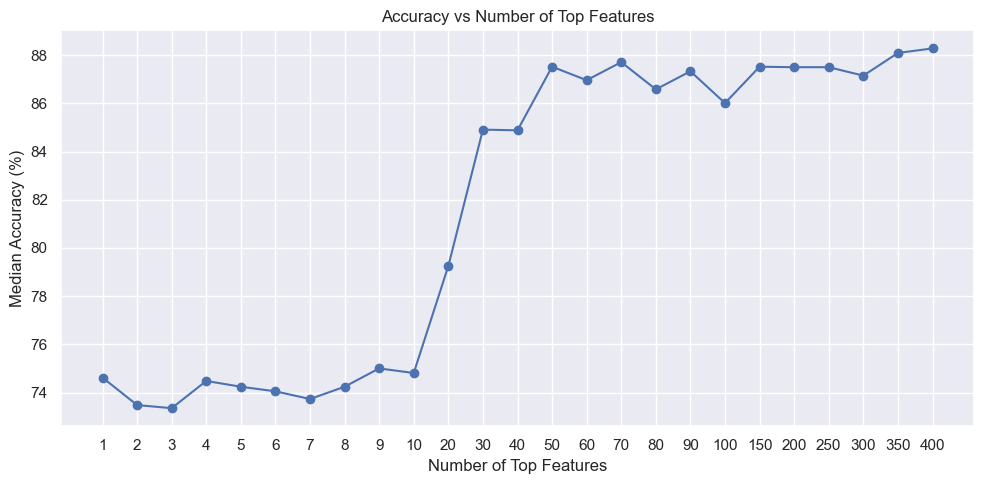

In [ ]:
# ==================================================
# Plot accuracy vs number of features
# ==================================================

# Style
sns.set_theme(style="darkgrid")

# Data
x = results_df.index.astype(str)   # treat as categorical (discrete)
y = results_df["Median accuracy (%)"]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x, y, marker='o')

# Labels
plt.xlabel("Number of Top Features")
plt.ylabel("Median Accuracy (%)")
plt.title("Accuracy vs Number of Top Features")

# Improve readability
# plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

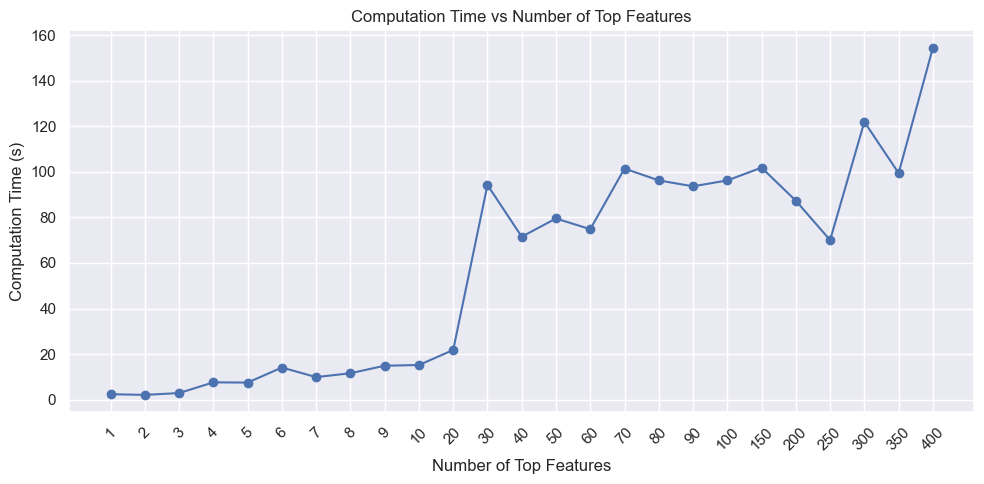

In [ ]:
# ==================================================
# Plot computation time vs number of features
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="darkgrid")

# Data (categorical x-axis)
x = results_df.index.astype(str)
y = results_df["Comp time (s)"]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x, y, marker='o')

# Labels
plt.xlabel("Number of Top Features")
plt.ylabel("Computation Time (s)")
plt.title("Computation Time vs Number of Top Features")

# Improve readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

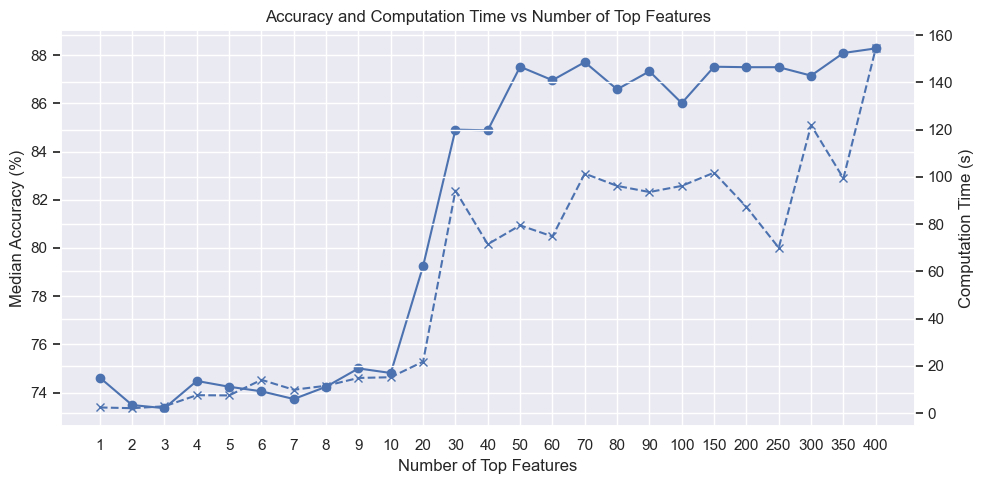

In [ ]:
# ==================================================
# Plot accuracy + computation time (dual axis)
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="darkgrid")

# Data (categorical x-axis)
x = results_df.index.astype(str)
y_acc = results_df["Median accuracy (%)"]
y_time = results_df["Comp time (s)"]

# Create figure
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: accuracy
ax1.plot(x, y_acc, marker='o')
ax1.set_xlabel("Number of Top Features")
ax1.set_ylabel("Median Accuracy (%)")

# Right axis: time
ax2 = ax1.twinx()
ax2.plot(x, y_time, linestyle='--', marker='x')
ax2.set_ylabel("Computation Time (s)")

# Title and formatting
plt.title("Accuracy and Computation Time vs Number of Top Features")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

By analysing the results, we can see that

In [121]:
# ==================================================
# Best n_features + feature names
# ==================================================

# Find n_features with highest median accuracy
best_n = results_df["Median accuracy (%)"].idxmax()
best_acc = results_df.loc[best_n, "Median accuracy (%)"]

# Get corresponding top features from correlation ranking
best_features = df_corr["abs_corr"].head(best_n).index.tolist()

# Output
print("\n", f"Best number of features: {best_n}")
print(f"Median accuracy: {best_acc:.2f} %\n")

print("Top features:")
for f in best_features:
    print(f)


 Best number of features: 400
Median accuracy: 88.28 %

Top features:
MSW_SINE_5
BBP_5_2.0
STOCHFk_5_3
CCI_14_0.015
TTM_TRND_6
PO_14
SMIo_5_20_5
BULLP_13
AOBV_SR_2
AOBV_LR_2
STOCHFd_5_3
J_9_3
CPR_WIDTH
PGO_14
WILLR_14
DSP_14
CPR_WIDTH_PCT
RVI_14
FOSC_14
AMATe_LR_8_21_2
AMATe_SR_8_21_2
LOGRET_1
PCTRET_1
BEARP_13
SLOPE_1
high_Z_30_1
DEC_1
open_Z_30_1
INC_1
close_Z_30_1
ZS_30
low_Z_30_1
RSI_14
CMO_14
PVR
K_9_3
BIAS_SMA_26
CFO_9
ROCR100_10
ROC_10
ROCP_10
ROCR_10
UO_7_14_28
STOCHRSIk_14_14_3_3
MOM_10
KVO_34_55_13
CDL_ENGULFING
EFI_13
CDL_HARAMI
STOCHk_14_3_3
PSL_12
VTXM_14
EBSW_40_10
MSW_LEAD_5
RVGIh_14_4
VTXP_14
DPO_20
SAREXT
PLUS_DM_14
DMP_14
SMI_5_20_5
MFI_14
MACDh_12_26_9
MACDEXTh_12_26_9
MACDFIXh_9_9
QS_10
ADOSC_3_10
LRSI_14
CG_10
FISHERT_9_1
QQE_14_5_4.236_RSIMA
CDL_3OUTSIDE
CDL_DOJISTAR
CTI_12
CDL_HANGINGMAN
CDL_HAMMER
D_9_3
BR_26
AROONOSC_14
QQEb_s_14_5_4.236
AROOND_14
CDL_SHOOTINGSTAR
QQEb_l_14_5_4.236
STOCHd_14_3_3
STOCHRSId_14_14_3_3
QQEd_14_5_4.236
CDL_INVERTEDHAMMER
INERTIA_20